In [3]:
# ==========================================
# 1. LIBRERÍAS
# ==========================================
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


📰 ¿Qué es el dataset 20 Newsgroups?

Es una colección de aproximadamente 20.000 artículos de foros (newsgroups) organizados en 20 categorías temáticas, por ejemplo:

comp.graphics (computación y gráficos)
rec.sport.baseball (deportes)
sci.space (ciencia y espacio)
talk.politics.misc (política)
alt.atheism (religión)

Cada documento es un texto real publicado en grupos de noticias en los años 90.

In [4]:
# ==========================================
# 2. CARGAR DATOS
# ==========================================
# Usaremos 4 categorías para hacerlo más rápido
categories = ['sci.space', 'rec.autos', 'talk.politics.mideast', 'comp.graphics']

data = fetch_20newsgroups(subset='all', categories=categories, remove=('headers', 'footers', 'quotes'))

X = data.data
y = data.target

print("Ejemplo de texto:\n", X[0][:301], "...\n")
print("Clases:", data.target_names)



Ejemplo de texto:
 I believe many people will be happy to have this information.   So, 
please post it to the comp.graphics. ...

Clases: ['comp.graphics', 'rec.autos', 'sci.space', 'talk.politics.mideast']


In [11]:
import random

print("Ejemplo de 5 textos aleatorios:")
for _ in range(5):
    print("-", random.choice(X)[:301], "...\n")

Ejemplo de 5 textos aleatorios:
-  ...

- Society
those
shaky

Now, I'm not saying you're wrong because I know that the R-12 substitutes  
exist, but this sounds a lot like the 200mpg carbs that the oil companies  
keep us all from getting. ...

- 

Actually, this is incorrect.  French resistance may have played some
part in hindering the German war effort, however the crucial role was
supplied on D-Day.


Interesting statement.  Especially when you consider that Lebanon
had claimed to have made progress in the peace talks, as well as
Israel.  ...

- 
If you don't already know it, you should call the bank/credit union/
finance company that holds the loan on your present car and get the
current payoff cost.

If you are trading in your current car on the new car, subtract the
payoff amount from the trade-in the dealer is giving you.  (If this
turns ...

- 
Since the DC-X is to take off horizontal, why not land that way??
Why do the Martian Landing thing..  Or am I missing something.. Don

In [12]:
# ==========================================
# 3. DIVISIÓN TRAIN/TEST
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
# ==========================================
# 4. PREPROCESAMIENTO DE TEXTO
# ==========================================
# Convertir texto en matriz de conteos de palabras
count_vect = CountVectorizer(stop_words='english')
X_train_counts = count_vect.fit_transform(X_train)
X_test_counts = count_vect.transform(X_test)

# Aplicar TF-IDF (opcional, mejora resultados)
tfidf = TfidfTransformer()
X_train_tfidf = tfidf.fit_transform(X_train_counts)
X_test_tfidf = tfidf.transform(X_test_counts)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 198237 stored elements and shape (2723, 32167)>

In [16]:
# Ejemplo rápido de CountVectorizer con algunos datos de muestra
from sklearn.feature_extraction.text import CountVectorizer

# Tomamos los primeros 5 textos para el ejemplo
sample_data = X[:5]

# Creamos una instancia de CountVectorizer
vectorizer_example = CountVectorizer()

# Ajustamos y transformamos los datos de muestra
X_sample_counts = vectorizer_example.fit_transform(sample_data)

# Mostramos el vocabulario aprendido
print("Vocabulario:", vectorizer_example.get_feature_names_out()[:20], "...") # Mostramos solo las primeras 20 palabras

# Mostramos la matriz de conteo para los datos de muestra
print("\nMatriz de conteo (primeras 5 filas, 20 columnas):")
print(X_sample_counts[:5, :20].todense()) # .todense() para ver la matriz completa (para ejemplos pequeños)

Vocabulario: ['above' 'act' 'advance' 'afterwhich' 'agree' 'all' 'also' 'am' 'amal'
 'and' 'another' 'are' 'argument' 'arms' 'as' 'assume' 'at' 'attempts'
 'be' 'bearing'] ...

Matriz de conteo (primeras 5 filas, 20 columnas):
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [1 1 0 1 1 0 2 1 1 4 1 2 1 1 3 1 0 1 5 1]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 3 0 0 0 0 0 0 2 0 0 0]]


**Explicación:**

`CountVectorizer` convierte una colección de documentos de texto en una matriz de conteos de tokens (palabras).

1.  **`vectorizer_example = CountVectorizer()`**: Creamos un objeto `CountVectorizer`.
2.  **`X_sample_counts = vectorizer_example.fit_transform(sample_data)`**: Este paso hace dos cosas:
    *   **`fit`**: Aprende el vocabulario de las palabras únicas en `sample_data`.
    *   **`transform`**: Convierte los documentos en una matriz donde cada fila es un documento y cada columna es una palabra del vocabulario. El valor en cada celda es el número de veces que esa palabra aparece en ese documento.
3.  **`vectorizer_example.get_feature_names_out()`**: Te da la lista de palabras en el vocabulario aprendido.
4.  **`X_sample_counts`**: Es la matriz que resulta de la transformación.

En resumen, transforma tus textos en números para que el modelo de Machine Learning pueda trabajar con ellos.

In [17]:
# ==========================================
# 5. MODELO MULTINOMIAL NAIVE BAYES
# ==========================================
model = MultinomialNB(alpha=1.0)  # alpha = parámetro de suavizado de Laplace
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

# ==========================================
# 6. EVALUACIÓN
# ==========================================
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=data.target_names))



Exactitud: 0.887

Matriz de confusión:
 [[269   6  17   6]
 [  7 255  25  23]
 [ 20   4 265   9]
 [  2   5   8 246]]

Reporte de clasificación:
                        precision    recall  f1-score   support

        comp.graphics       0.90      0.90      0.90       298
            rec.autos       0.94      0.82      0.88       310
            sci.space       0.84      0.89      0.86       298
talk.politics.mideast       0.87      0.94      0.90       261

             accuracy                           0.89      1167
            macro avg       0.89      0.89      0.89      1167
         weighted avg       0.89      0.89      0.89      1167



El modelo predice a qué categoría temática (de las 4 seleccionadas) pertenece cada texto nuevo.
Intenta adivinar si un artículo es sobre gráficos, autos, espacio o política basado en su contenido.

In [20]:
# ==========================================
# 8. EJEMPLO DE PREDICCIÓN
# ==========================================

# Crear 5 textos de ejemplo en inglés
example_texts = [
    "NASA will launch a new space telescope next year to study distant galaxies.",
    "The new electric car model has a range of 500 km and fast charging.",
    "Peace negotiations in the Middle East are progressing slowly, with positions still far apart.",
    "A new algorithm for rendering 3D graphics in real time was presented.",
    "I'm looking for information on how to repair my car's engine."
]

# Preprocesar los textos de ejemplo usando los mismos vectorizadores y transformadores
example_counts = count_vect.transform(example_texts)
example_tfidf = tfidf.transform(example_counts)

# Realizar predicciones
predicted_categories = model.predict(example_tfidf)

# Mostrar los resultados
print("Ejemplos de predicción:")
for i, text in enumerate(example_texts):
    predicted_category_name = data.target_names[predicted_categories[i]]
    print(f"\nTexto: {text}")
    print(f"Categoría predicha: {predicted_category_name}")

Ejemplos de predicción:

Texto: NASA will launch a new space telescope next year to study distant galaxies.
Categoría predicha: sci.space

Texto: The new electric car model has a range of 500 km and fast charging.
Categoría predicha: rec.autos

Texto: Peace negotiations in the Middle East are progressing slowly, with positions still far apart.
Categoría predicha: talk.politics.mideast

Texto: A new algorithm for rendering 3D graphics in real time was presented.
Categoría predicha: comp.graphics

Texto: I'm looking for information on how to repair my car's engine.
Categoría predicha: rec.autos


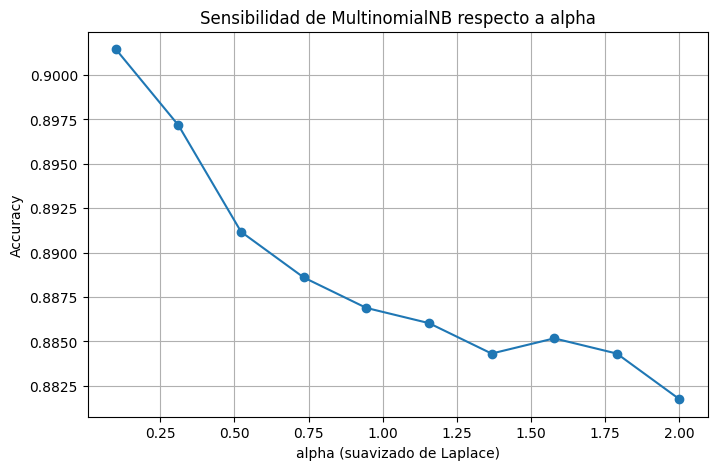

In [19]:
# ==========================================
# 7. ANÁLISIS DE SENSIBILIDAD (alpha)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

alphas = np.linspace(0.1, 2, 10)
accuracies = []

for a in alphas:
    model = MultinomialNB(alpha=a)
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure(figsize=(8,5))
plt.plot(alphas, accuracies, marker='o')
plt.title("Sensibilidad de MultinomialNB respecto a alpha")
plt.xlabel("alpha (suavizado de Laplace)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()